In [ ]:
import marimo as mo
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

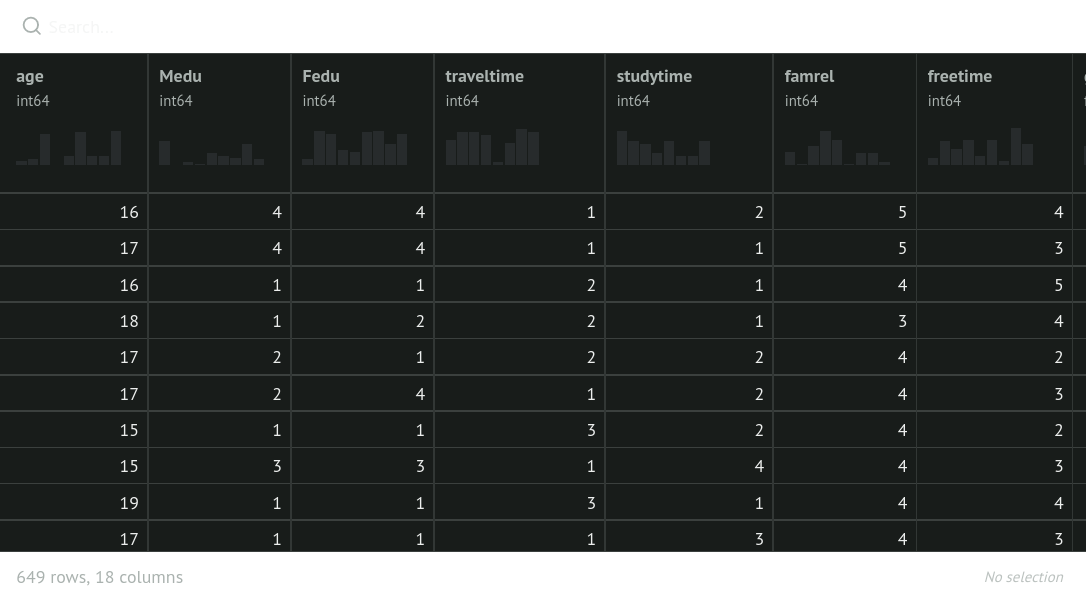

In [ ]:
dat = pd.read_csv("src/taks_linreg/data.csv")
bad = dat["plans_universitypast_failures"].to_numpy()
dat["plans_university"] = abs(bad) // 10 * bad // abs(bad)
dat["past_failures"] = abs(bad) % 10
dat = dat.drop(columns=["plans_universitypast_failures"])
dat

### Задача 2: пропуски в данных
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

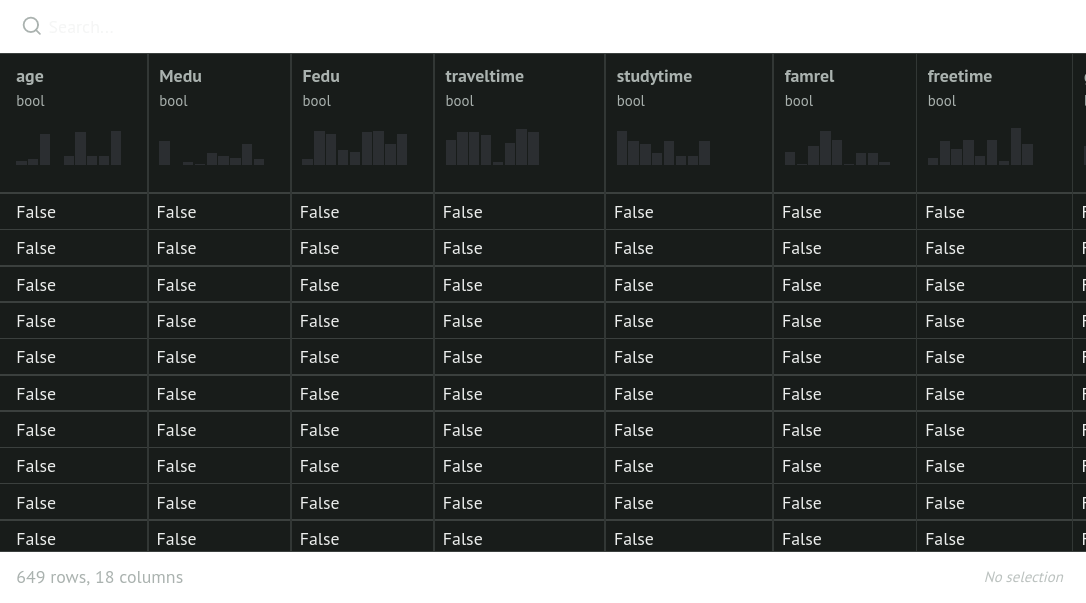

In [ ]:
dat.fillna(dat.mean(), inplace=True)
dat.isnull()

### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [ ]:
ndat = dat.copy()
ndat /= ndat.std()
ndat -= ndat.mean()

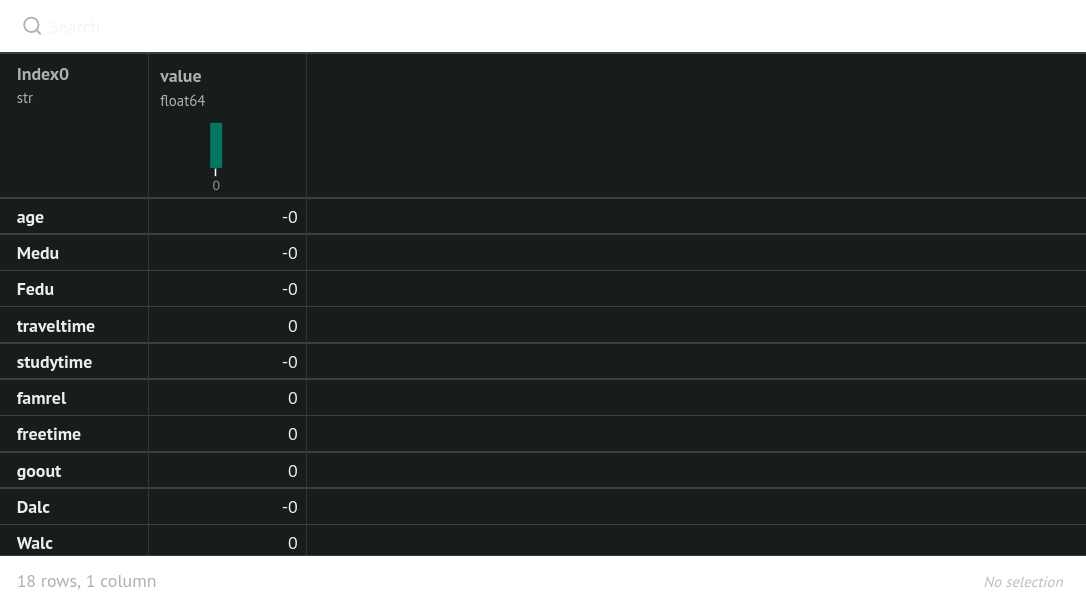

In [ ]:
ndat.mean().round()

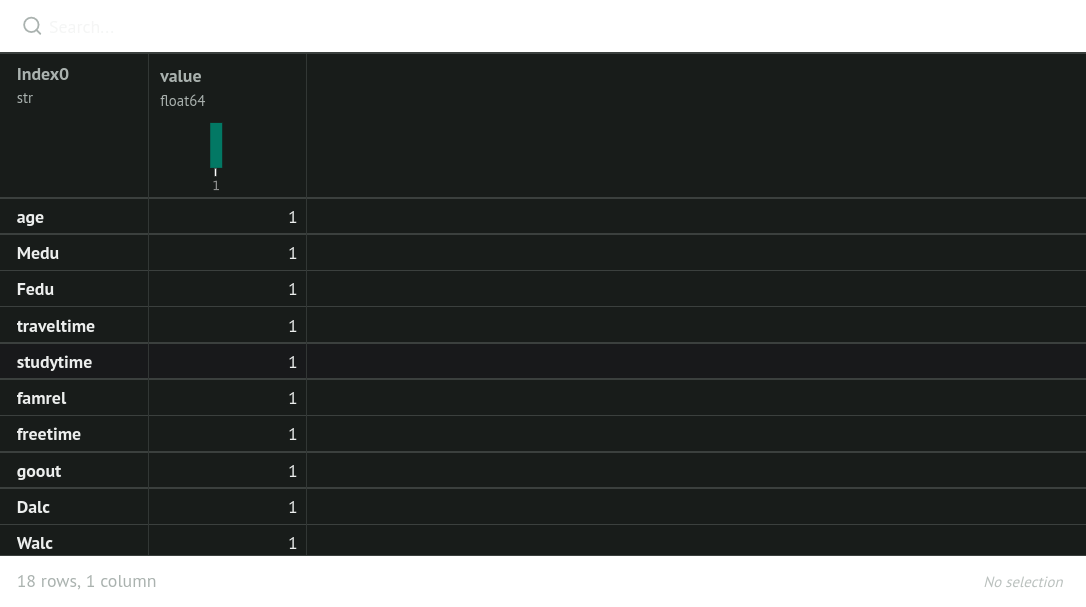

In [ ]:
ndat.std().round()

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [ ]:
dans = pd.read_csv("src/taks_linreg/scores.csv", names=["ans"]).to_numpy().ravel()
model = sklearn.linear_model.SGDRegressor()
print(*sklearn.model_selection.cross_validate(model, X=ndat, y=dans, cv=4, scoring="neg_mean_squared_error")["test_score"], sep="\n")

-170.77714701422818
-243.30739254378133
-242.63582922466395
-229.5721879455685


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

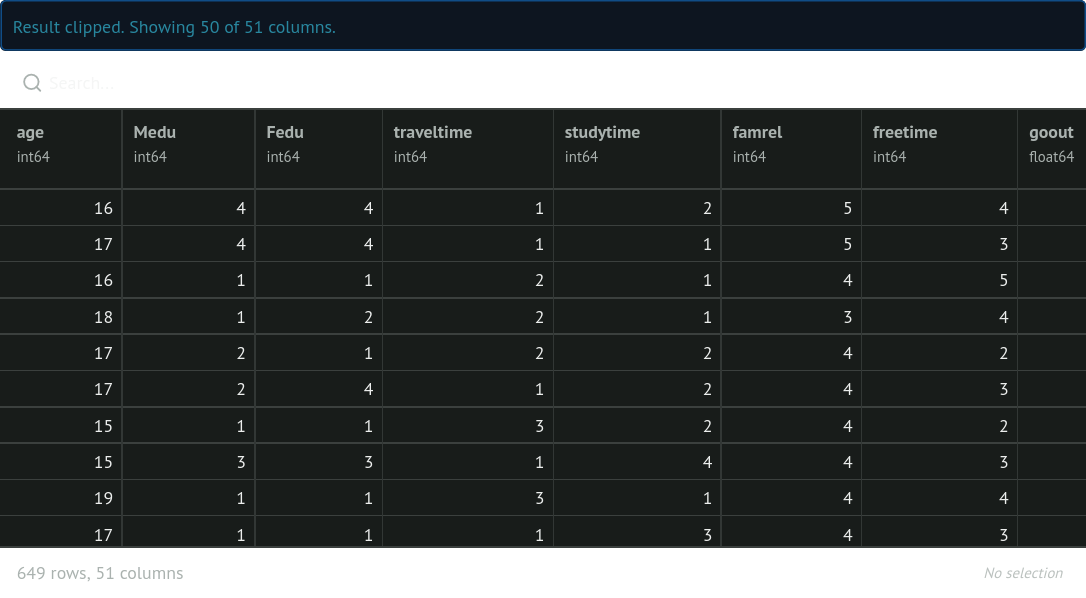

In [ ]:
att = pd.read_csv("src/taks_linreg/attendance.csv",sep=";").replace("+", 1).fillna(0)
ss = np.zeros(len(dat))
ss[np.genfromtxt("src/taks_linreg/school_support.txt", dtype=np.uint)] = 1
dat2 = dat.copy()
dat2["school_support"] = ss
dat2.join(att, how="left")

In [ ]:
ndat2 = dat2.copy()
ndat2 /= ndat2.std()
ndat2 -= ndat2.mean()

In [ ]:
model2 = sklearn.linear_model.SGDRegressor(max_iter=10000)
print(*sklearn.model_selection.cross_validate(model2, X=ndat2, y=dans, cv=4, scoring="neg_mean_squared_error")["test_score"], sep="\n")

-165.40085926944684
-236.76873148958606
-250.12467191636222
-230.313180491166


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

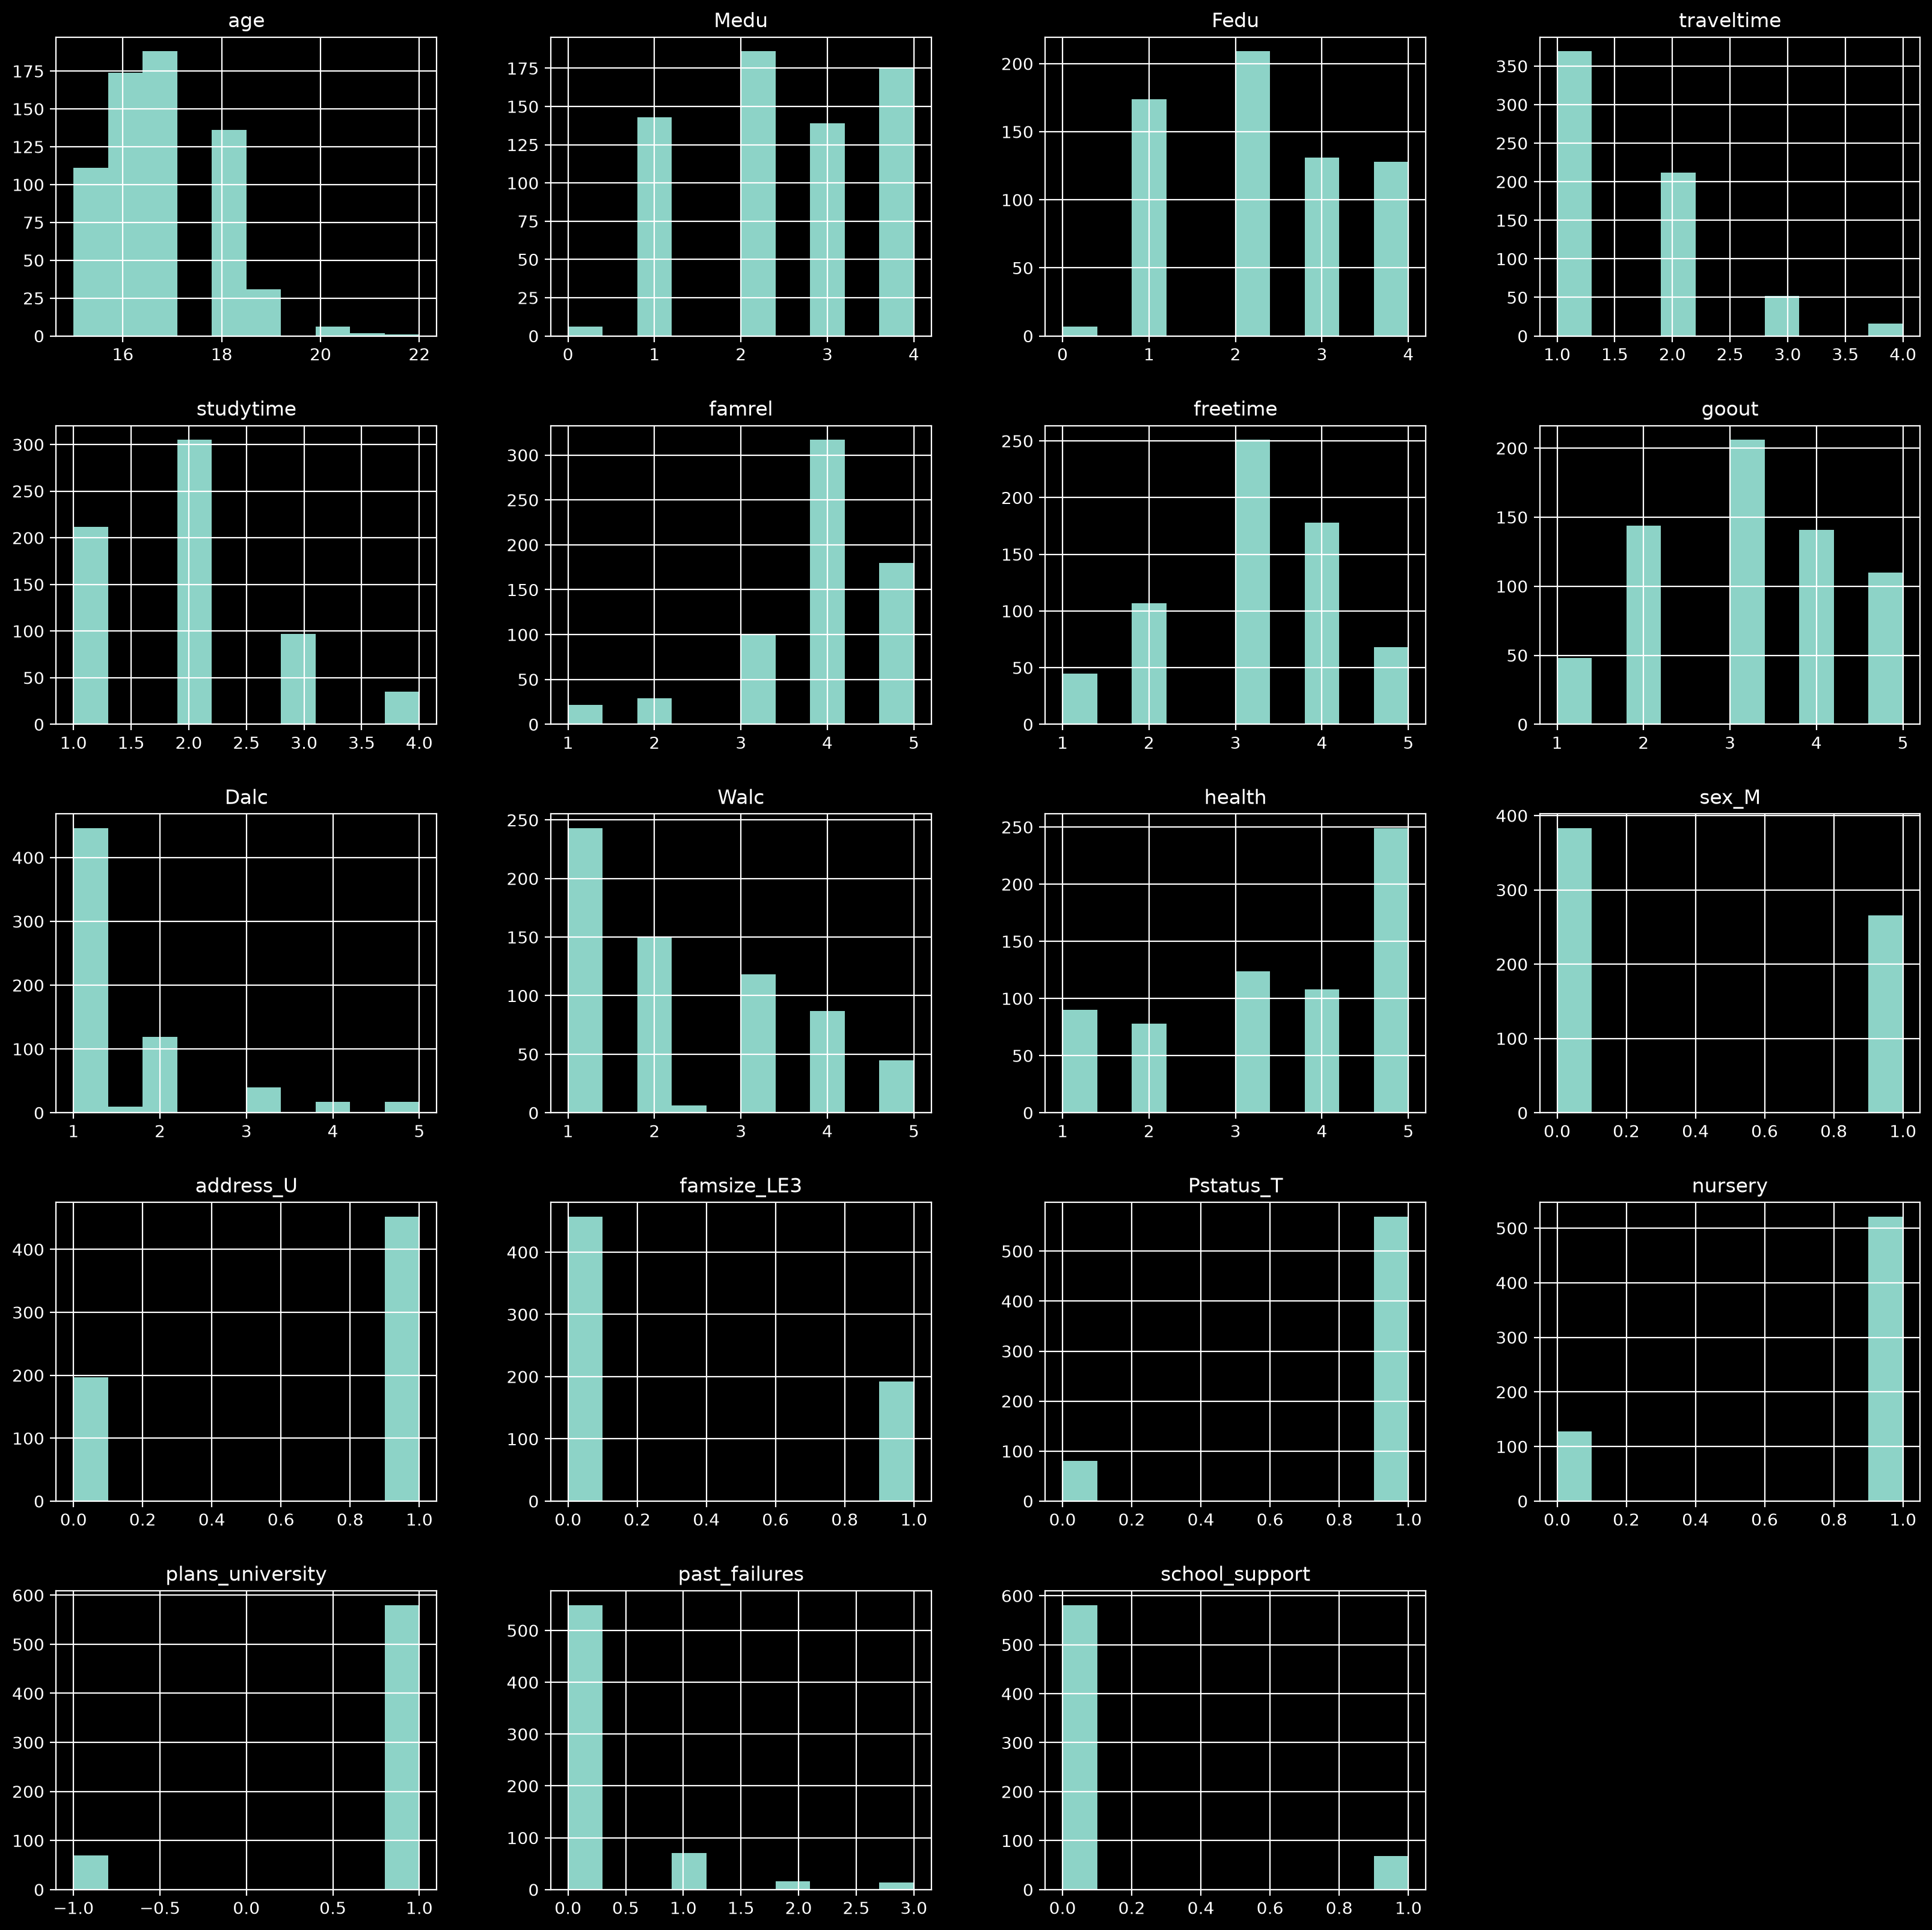

In [ ]:
dat3 = dat2.copy()
dat3.loc[dat3["traveltime"] > 4, "traveltime"] = dat3["traveltime"].median()
dat3.loc[dat3["age"] > 100, "age"] = dat3["age"].median()
dat3.hist(figsize=(20, 20))
plt.show()

In [ ]:
ndat3 = dat3.copy()
ndat3 /= ndat3.std()
ndat3 -= ndat3.mean()

In [ ]:
model3 = sklearn.linear_model.SGDRegressor(max_iter=10000)
print(*sklearn.model_selection.cross_validate(model3, X=ndat3, y=dans, cv=4, scoring="neg_mean_squared_error")["test_score"], sep="\n")

-159.63915461307195
-237.71143950038058
-245.52531566531584
-233.5179608559296


__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

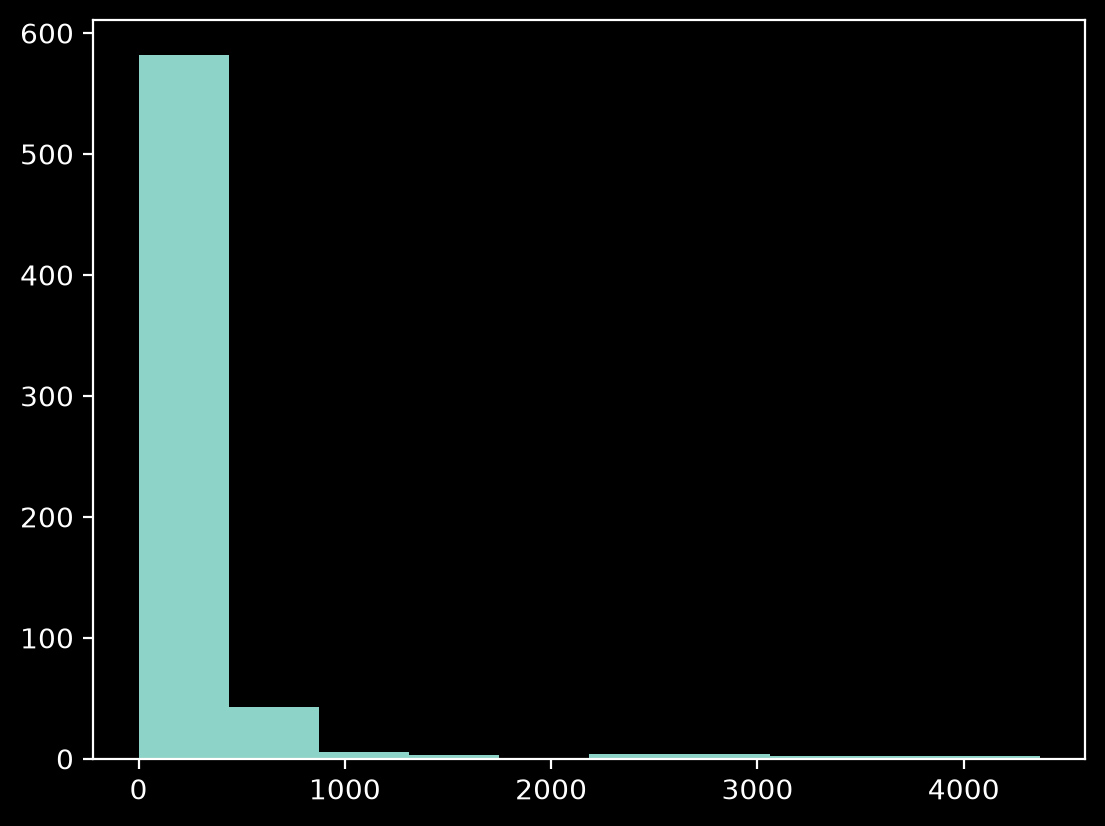

In [ ]:
regression = sklearn.linear_model.LinearRegression().fit(ndat3, dans)
prediction = regression.predict(ndat3)
error = (prediction - dans)**2
ndat4 = ndat3[error <= 2000]
dans4 = dans[error <= 2000]
plt.hist(error)
plt.show()

### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных.

In [ ]:
model4 = sklearn.linear_model.SGDRegressor(max_iter=10000)
print(*sklearn.model_selection.cross_validate(model4, X=ndat4, y=dans4, cv=4, scoring="neg_mean_squared_error")["test_score"], sep="\n")

-158.85095905751123
-159.33572528142366
-135.19560172950975
-133.78758094907027
